In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv('../Dataset/vehicles.csv')
print(f"Cantidad de filas: {df.shape[0]:,}  -  Cantidad de columnas: {df.shape[1]}")

Cantidad de filas: 426,880  -  Cantidad de columnas: 26


In [ ]:
# Tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [8]:
# Inspección inicial de los datos

df.head(150)

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,7304134738,https://auburn.craigslist.org/ctd/d/auburn-uni...,auburn,https://auburn.craigslist.org,31590,2017.0,jeep,wrangler unlimited sport,good,6 cylinders,...,NaN,SUV,black,https://images.craigslist.org/00W0W_buOjh5s1Qh...,Carvana is the safer way to buy a car During t...,NaN,al,32.59,-85.48,2021-04-09T09:31:05-0500
146,7304111898,https://auburn.craigslist.org/ctd/d/auburn-uni...,auburn,https://auburn.craigslist.org,30990,2017.0,jeep,wrangler unlimited sport,good,6 cylinders,...,NaN,SUV,silver,https://images.craigslist.org/00j0j_BfPLW19l2F...,Carvana is the safer way to buy a car During t...,NaN,al,32.59,-85.48,2021-04-09T08:51:07-0500
147,7303661415,https://auburn.craigslist.org/ctd/d/auburn-uni...,auburn,https://auburn.craigslist.org,14590,2012.0,bmw,1 series 128i coupe 2d,good,NaN,...,NaN,coupe,black,https://images.craigslist.org/00F0F_5UAXmOzC18...,Carvana is the safer way to buy a car During t...,NaN,al,32.59,-85.48,2021-04-08T10:41:14-0500
148,7303661350,https://auburn.craigslist.org/ctd/d/auburn-uni...,auburn,https://auburn.craigslist.org,20590,2018.0,chrysler,300 limited sedan 4d,good,6 cylinders,...,NaN,sedan,black,https://images.craigslist.org/00x0x_ga6n3ZpljY...,Carvana is the safer way to buy a car During t...,NaN,al,32.59,-85.48,2021-04-08T10:41:10-0500


In [9]:
# Estadísticas descriptivas

df.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


Filas eliminadas por precio (Outliers/Ruido): 42,749


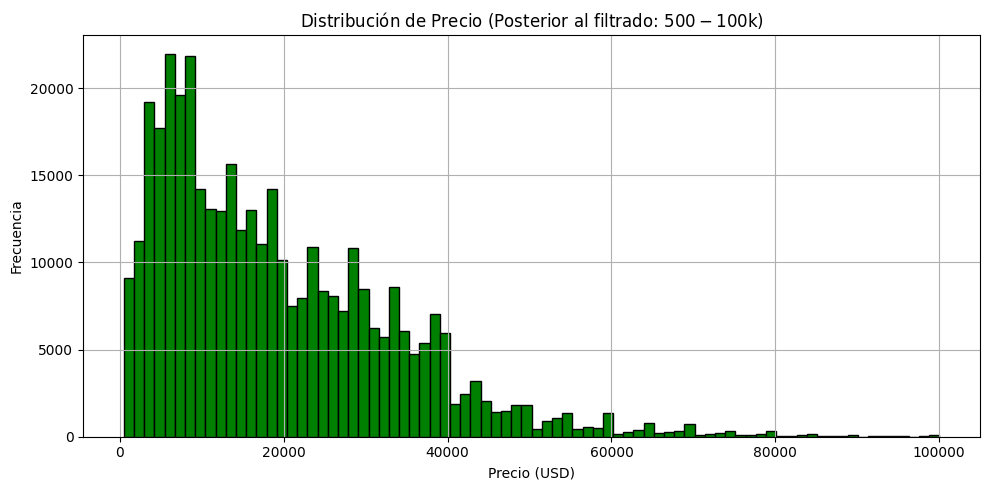

In [ ]:
# Distribución de variables numéricas

# Price
# Filtrar el precio entre $500 y $100,000 (rango comercial lógico)
df_precio = df[(df['price'] >= 500) & (df['price'] <= 100000)].copy()
print(f"Filas eliminadas por precio (Outliers/Ruido): {len(df) - len(df_precio):,}")

plt.figure(figsize=(10, 5))
df_precio['price'].hist(bins=80, color='green', edgecolor='black')
plt.title('Distribución de Precio (Posterior al filtrado: $500 - $100k)')
plt.xlabel('Precio (USD)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('precio_distribucion.png', dpi=150)
plt.show()


In [ ]:
# Distribución de variables numéricas

# Year
# Filtrar años entre 1990 y 2022
df_year = df[(df['year'] >= 1990) & (df['year'] <= 2022)].copy()
print(f"Filas eliminadas por año (Antiguos/Errores): {len(df) - len(df_year):,}")

plt.figure(figsize=(10, 5))
df_year['year'].hist(bins=32, color='darkorange', edgecolor='black')
plt.title('Distribución por Año (Posterior al filtrado: 1990 - 2022)')
plt.xlabel('Año del Modelo')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('year_distribucion.png', dpi=150)
plt.show()